In [7]:
from datasets import load_dataset
import sounddevice as sd # To run sound using data as array and the sample rate
from datasets import Audio
from torch.utils.data import DataLoader
import numpy as np
from matplotlib import pyplot as plt
# import torchcodec
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch import Trainer
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [91]:
!pip install torchcodec

   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ------------- -------------------------- 1.0/3.1 MB 12.5 MB/s eta 0:00:01
   ------------------------------------ --- 2.9/3.1 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 3.1/3.1 MB 6.8 MB/s  0:00:00


In [4]:
dataset1 = load_dataset("MBZUAI/ClArTTS")
dataset2 = load_dataset("MohamedRashad/common-voice-18-arabic")
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/21 [00:00<?, ?it/s]

In [3]:
help(load_dataset)

Help on function load_dataset in module datasets.load:

load_dataset(path: str, name: Optional[str] = None, data_dir: Optional[str] = None, data_files: Union[str, collections.abc.Sequence[str], collections.abc.Mapping[str, Union[str, collections.abc.Sequence[str]]], NoneType] = None, split: Union[str, datasets.splits.Split, list[str], list[datasets.splits.Split], NoneType] = None, cache_dir: Optional[str] = None, features: Optional[datasets.features.features.Features] = None, download_config: Optional[datasets.download.download_config.DownloadConfig] = None, download_mode: Union[datasets.download.download_manager.DownloadMode, str, NoneType] = None, verification_mode: Union[datasets.utils.info_utils.VerificationMode, str, NoneType] = None, keep_in_memory: Optional[bool] = None, save_infos: bool = False, revision: Union[datasets.utils.version.Version, str, NoneType] = None, token: Union[bool, str, NoneType] = None, streaming: bool = False, num_proc: Optional[int] = None, storage_options

# Notes

## Augmentation Related
### Note 1
The model should be time wrapping invariance (able to handle different sampling rate)
To that end, it is important to have a resampling augmentation
### Note 2
The input can be as long as 40100 data points if the model were to handle one second at a time.
This can make the model quite large, thus, this input will need to be split, or projected down
to make sure the model size will stay relatively small.


## Architecture Related
### Note 1
Using an encoder and decoder together might be better than just using an encoder or a decoder.
The idea is the encoder will get information about a larger chunk, let's say 5-10 seconds, while
the decoder will process 1 second at a time. This means the encoder will gain insight about 
a larger chunk, (more global attention), this means it will figure out which sound effect to 
remove and which one to keep. Maybe a sound effect is needed, such as a mouse click, and maybe
it is noise, so this larger attention might help in those kind of scenarios.

# Visualizing Data

In [28]:
dataset1.keys()

dict_keys(['train', 'test'])

In [27]:
dataset1["train"][0].keys()

dict_keys(['text', 'file', 'audio', 'sampling_rate', 'duration'])

In [10]:
dataset2

DatasetDict({
    train: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_rows: 28410
    })
    validation: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_rows: 10471
    })
    test: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_rows: 10471
    })
    other: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_rows: 41586
    })
    invalidated: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_

In [ ]:
dataset2["train"].cast_column("audio", Audio(sampling_rate=48_000))[0]

In [ ]:
# audios = [audio["audio"] for audio in dataset1["train"]] 
# len(dataset1["train"])
# audios = []
# step = 100
# n = 0

# for audio_info in dataset1["train"]:
#     audios.append(audio_info["audio"])
#     n += 1
#     if n % step == 0 and n != 0:
#         print("Completed ", n, " out of ", len(dataset1["train"]))

In [40]:
exampleAudioI = 1000
audio_e_data = dataset1["train"][exampleAudioI]["audio"]
audio_e_samplerate = dataset1["train"][exampleAudioI]["sampling_rate"]

In [41]:
sd.play(data=audio_e_data, samplerate=audio_e_samplerate)

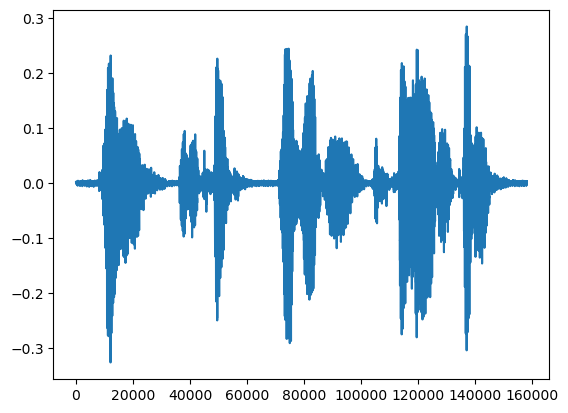

In [43]:
plt.plot(audio_e_data)

# Merge Datasets

# Dataset Augmentation

In [ ]:
def get_rms(records):
    return math.sqrt(sum([x ** 2 for x in records]) / len(records))
    
def get_random_part(array, chunk_size):
    if len(array) < chunk_size:
        print("Array size:(", len(array), ") is less then the chunk_size: (", chunk_size, ") in 'get_random_part'")
        pad_width = chunk_size - len(arr)
        return np.pad(arr, (0, pad_width), constant_values=pad_value)
    else:
        diff_size = len(array) - chunk_size
        start = np.random.randint(0, diff_size)
        return array[start:(start + chunk_size)]

# Test
plt.plot(get_random_part(audio_e_data, audio_e_samplerate))

In [68]:
class AgumenterDataset(Dataset):
    def __init__(self, speech_data, music_data, chunk_size):
        super().__init__()
        self.speech_data = speech_data
        self.music_data = music_data
        self.chunk_size = chunk_size

    def __len__(self):
        return len(self.speech_data)

    def __getitem__(self, i):
        speech = self.speech_data[i]
        music_i = np.random.randint(0, len(music_data))
        music = self.music_data[music_i]

        # Select part of the speech and music equivalent to chunk_size
        speech_chunk = get_random_part(speech, self.chunk_size)
        music_chunk = get_random_part(music, self.chunk_size)

        # Calculate signal to noise ratio, and adjust the music based on that
        snr_db = np.random.uniform(-7, 2) # Training samples noise in the range of -7 to 2 snr
        snr = 10 ** (0.1 * (snr_db))
        coe=get_rms(speech_chunk)/(get_rms(music_chunk)*snr)
        music_chunk *= coe
        mixed_audio = speech_chunk + music_chunk

        return mixed_audio, speech_chunk, music_chunk
        

# Model

In [ ]:
class MusicRemoverLayer(nn.Module):
    def __init__(self, chunk_size, d_model=32, nhead=4):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            dropout=0.1, # default
            activation="gelu",
            bias=True,
            nhead=nheads, # Might be better to have multiple head, each focusing on different type of info
            dim_feedforward=chunk_size,
            batch_first=True, # Shape (B, Seq, D_model)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer)

    def forward(self, x): # Input must be (B, Seq, D_model)!
        music_noise = self.transformer(x)
        cleaned_x = (x - noise)
        return cleaned_x

In [ ]:
# Transformer model for signal input
class LinearProjectionLayer(nn.Module):
    def __init__(self, from_size, to_size, last=False):
        super().__init__()
        self.linear = nn.Linear(from_size, to_size)


    def forward(self, x):
        # x shape: # (B, 1, S)
        if !last:
            x = x.permute(0, 2, 1)
        x = self.linear(x)              # (B, S, 1)

        if !last:
            out = x.permute(0, 2, 1)
        else:
            out = x
        # print(out.shape)
        return out

In [ ]:
class Encoder(nn.Module):
    def __init__(self, chunk_size, chunks, d_model, nhead, latent):
        super().__init__()
        self.input_dim = 1
        self.layer = nn.Sequential(
            nn.LinearProjectionLayer(chunk_size * chunks, chunk_size), # Decrease sequence length
            nn.LinearProjectionLayer(chunk_size, chunk_size / 2), # Decrease sequence length
            nn.LinearProjectionLayer(chunk_size / 2, latent), # Decrease sequence length to latent (aligning latent space)
            nn.LinearProjectionLayer(self.input_dim, d_model, last=True), # increase/decrease dimensions to d_model
            MusicRemoverLayer(chunk_size = chunk_size / 4, d_model = d_model, nhead = nhead), # I need to test on multiple layers
        )

    def forward(self, x):
        return self.layer(x) # output shape (B, latent, d_model)

In [ ]:
class Decoder(nn.Module):
    def __init__(self, chunk_size, d_model, nhead, latent):
        super().__init__()
        self.input_dim = 1
        self.layer = nn.Sequential(
            nn.LinearProjectionLayer(chunk_size, chunk_size / 2), # Decrease sequence length
            nn.LinearProjectionLayer(chunk_size / 2, latent), # Decrease sequence length to latent (aligning latent space)
            nn.LinearProjectionLayer(self.input_dim, d_model, last=True), # increase/decrease dimensions to d_model
            MusicRemoverLayer(chunk_size = chunk_size / 4, d_model = d_model, nhead = nhead), # I need to test on multiple layers
            # I project down to 1 dim, then increase seq length for efficency purposes. However, the opposite could be tested
            nn.LinearProjectionLayer(d_model, self.input_dim, last=True), # convert dimension back to input_dim
            nn.LinearProjectionLayer(d_model, self.input_dim), # convert seq length back to chunk_size
        )

    def forward(self, x):
        return self.layer(x) # output shape (B, chunk_size, 1)

In [ ]:
class MusicRemoverModel(L.LightningModule):
    def __init__(self, chunk_size=250, d_model=32, nhead=4, latent=512):
        super().__init__()
        self.save_hyperparameters()
        slef.layer = nn.Sequential(
          Decoder(chunk_size=chunk_size, d_model=d_model, nhead=nhead, latent=512)
        );
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.layer(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        predicted_y = self(x)
        loss = self.loss_fn(predicted_y, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def configure_optimizers(self):
        self.optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-2)
        return self.optimizer